# Study 774 — Nintendo-Direct — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `a7162a8938fd`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from nintendo_direct import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching NTDOY + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} Directs resolved")


panel loaded; 25 of 25 Directs resolved


## 1. One-sample *t* across independent Directs

Each Direct is one independent event, so the unit is a one-sample *t* of the per-event abnormal return — **not** a daily panel (which would fake precision).

In [2]:
for label, col in [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<12s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

2wk run-up   n=25  mean=-1.474%  sd=4.75%  t=-1.552
1mo run-up   n=25  mean=-1.203%  sd=8.74%  t=-0.688
2wk fade     n=25  mean=+0.925%  sd=5.98%  t=+0.774
1mo fade     n=25  mean=-0.096%  sd=8.99%  t=-0.053


## 2. Random-window placebo — is the dip inside the luck cloud?

For each event we redraw a random, non-Direct 2-week window on NTDOY vs SPY and recompute the abnormal return; 20 seeds × 200 draws. If the observed mean sits in the tail of that null, it isn't ordinary tracking noise. Here it does not.

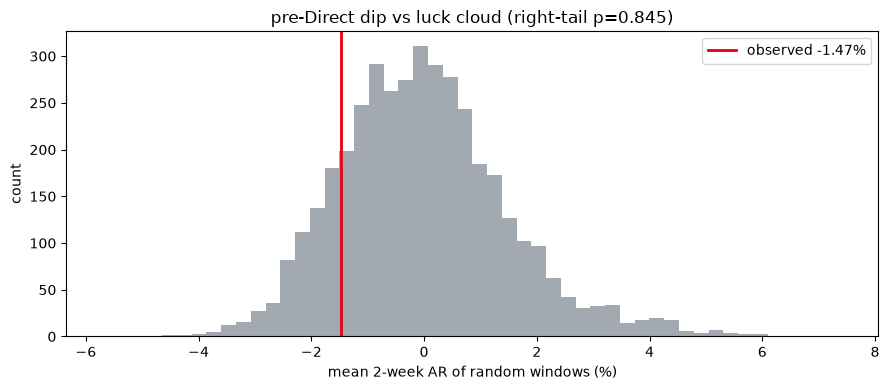

placebo: {'obs': -0.0147, 'placebo_mean': -0.0003, 'placebo_sd': 0.0151, 'p_value': 0.8445, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'pre_s', k=10, tail='right')
import numpy as np
ntdoy, spy = prices[dt.INSTRUMENT], prices[dt.BENCHMARK]
common = ntdoy.index.intersection(spy.index).sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-11))
        vals.append(float(ntdoy.loc[common[p+10]]/ntdoy.loc[common[p]] - spy.loc[common[p+10]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#e60012', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 2-week AR of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"pre-Direct dip vs luck cloud (right-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the dip one bad Direct, or broad?

In [4]:
x = inc['pre_s'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = -1.552
jackknife t range [-1.829, -1.140] over 25 leave-one-out draws


## 4. Tradability — net of costs (and the look-ahead problem)

Even gross there is no significant edge; costs only enlarge the (untradeable) short of a negative window. And the entry date isn't known 2 weeks out — Directs are announced ~1-3 days ahead — while NTDOY is a thin OTC ADR with wide spreads.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('pre_s','2wk run-up'),('post_s','2wk fade')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<12s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

2wk run-up   gross -1.474% (t=-1.55)  net@5 -1.574% (t=-1.66)  net@10 -1.674% (t=-1.76)
2wk fade     gross +0.925% (t=+0.77)  net@5 +0.825% (t=+0.69)  net@10 +0.725% (t=+0.61)


## 5. Synthetic positive control — the detector works; the tape has no bump

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted pre-Direct bump. At n = 25 with a 10-day AR the null fires |*t*| ≥ 2 on only ~2/20 seeds — an honest, modest false-positive rate — and a real planted bump is recovered monotonically. The machinery is fine; the real NTDOY tape simply has nothing to find.

null: mean t=-0.25 sd=1.06  |t|>=2 in 2/20 seeds
planted +1%: mean AR +1.659%  t=+1.44
planted +2%: mean AR +2.659%  t=+2.31


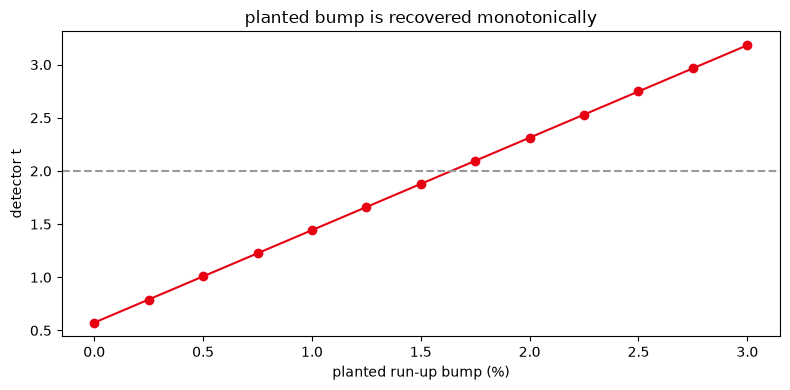

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=778+s, k=10)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.01, 0.02):
    r = st.synthetic_detect(bump=b, seed=778, k=10)
    print(f'planted +{b*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.03, 13)
ts = [st.synthetic_detect(bump=b, seed=778, k=10)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#e60012')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted run-up bump (%)'); ax.set_ylabel('detector t')
ax.set_title('planted bump is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: None.** Neither half of the folklore survives — the run-up is an insignificant mild dip (*t* = −1.55, placebo right-tail ≈ 0.84, hit 40%) and the fade is a clean zero (|*t*| < 0.8). Nothing reaches significance or a placebo tail, while the synthetic control shows a real bump *would* have been caught. **Tradability: Mirage.** No edge gross or net, the entry date isn't known 2 weeks out (Directs announced ~1-3 days ahead), and NTDOY is a thin OTC ADR.